# Hierarchical Ellipticity fitting (numpyro)

Here I fit a number of ellipticity models hierarchically using numpyro

In [1]:
%matplotlib inline

In [1]:
import numpy as np
import arviz as az
import arviz_plots as azp
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from tensorflow_probability.substrates import jax as tfp
from numpyro.infer import MCMC, NUTS
import matplotlib.pyplot as plt
numpyro.set_host_device_count(8)
import seaborn as sns
import pandas as pd

c:\Users\nateh\pulsarSearch\Pulsar_Ellipticity_Inference\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
jax.local_device_count()
from jax import config
jax.config.update("jax_enable_x64", True)
numpyro.enable_x64()

In [3]:
tfd = tfp.distributions

## Data Initializations

In [ ]:
# for reference, data used here is observables along axis 0, posterior samples along axis 1
# Full data, NaN=0
# data: eps_samples_stack [array, ObservablesxSamples]
# bin size: bws [array, 1xObservations]
# nan mask: nan_mask [array, ObservablesxSamples]
# row count: sample_count_per_row [array, 1xObservables]

max_obs = 4090
posteriors = pd.read_csv("eps_samples_stack.csv", header=None, names=range(max_obs))
eps_raw = posteriors.to_numpy()

nan_mask = ~np.isnan(eps_raw)
sample_count_per_row = nan_mask.sum(axis=1)

#eps_scaled_raw = eps_raw * 1e7
bws = np.nanstd(eps_raw, axis=1) / sample_count_per_row**(1.0/5.0)
#bws = np.clip(bws, min=1e-3) 

eps_samples_stack = np.nan_to_num(eps_raw,nan=0.0)

In [ ]:
# Clipped data, no NaN filtering beware, choose array size carefully
# data: clipped_posteriors [array, ObservablesxSamples]
# bin size: bws [array, 1xObservations]
# nan mask: nan_mask [array, ObservablesxSamples]
# row count: sample_count_per_row [array, 1xObservables]

max_obs = 4090
posteriors = pd.read_csv("eps_samples_stack.csv", header=None, names=range(max_obs))
clipped_posteriors = posteriors.iloc[:,:1000]
clipped_posteriors = clipped_posteriors.to_numpy()
sample_count_per_row = clipped_posteriors.shape[1]
bws = jnp.std(clipped_posteriors, axis=1) / sample_count_per_row**(1.0/5.0)
nan_mask = ~np.isnan(clipped_posteriors)


In [6]:
print(clipped_posteriors.shape)

(45, 1000)


### Test data

In [ ]:
# TEST DATA
# single hyperparameter on scale


scale_true = 3

Nobs = 100
Nsamp = 1000

sigma_obs = 0.1

fake_truths = np.random.exponential(scale_true, Nobs)
fake_obs = np.random.normal(0, sigma_obs, (Nobs, Nsamp)) + fake_truths[:,np.newaxis]

In [ ]:
# TEST DATA
# two hyperparameters on mean and spread

mu_true = 2
sigma_true = 1

Nobs = 100
Nsamp = 1000

sigma_obs = 0.1

fake_truths = np.random.normal(mu_true, sigma_true, Nobs)
fake_obs = np.random.normal(0, sigma_obs, (Nobs, Nsamp)) + fake_truths[:,np.newaxis]


## Models

### Gaussian

In [ ]:
# NO KDE

def gaussian_noKDE(eps_samples_stack, nan_mask, bws, sample_count_per_row, manual = False):

    lower_mean = 1e-10
    upper_mean = 1e-5
    mu = numpyro.sample('mu', dist.LogUniform(lower_mean,upper_mean))
    sigma = numpyro.sample('sigma', dist.LogUniform(lower_mean,upper_mean))
    
    def log_density(xs, m, s):
        return dist.Normal(m,s).log_prob(xs)
    
    epsilon_probs = log_density(eps_samples_stack, mu, sigma)

    e = numpyro.sample('epsilon', dist.Normal(mu, sigma))
    
    log_indv_obs_means = jax.nn.logsumexp(epsilon_probs, axis=0) - jnp.log(sample_count_per_row)

    numpyro.factor('log_likelihood', jnp.sum(log_indv_obs_means))

In [ ]:
# WITH KDE

def gaussian_KDE(eps_samples_stack, nan_mask, bws, sample_count_per_row, manual = False):

    lower_mean = 1e-10
    upper_mean = 1e-5
    mu = numpyro.sample('mu', dist.LogUniform(lower_mean,upper_mean))
    sigma = numpyro.sample('sigma', dist.LogUniform(lower_mean,upper_mean))
    
    total_sigma = jnp.sqrt(jnp.square(sigma) + bws**2)

    usable_eps = jnp.where(nan_mask,eps_samples_stack,0.0)
    
    def log_density(xs, m, s):
        return dist.Normal(m,s).log_prob(xs)
        
    epsilon_probs = log_density(usable_eps.T, mu, total_sigma)

    final_eps = jnp.where(nan_mask.T, epsilon_probs, -jnp.inf)
    
    log_indv_obs_means = jax.nn.logsumexp(final_eps, axis=0) - jnp.log(sample_count_per_row)

    numpyro.factor('log_likelihood', jnp.sum(log_indv_obs_means))

### Half Gaussian

In [ ]:
def half_gaussian(eps_samples_stack, nan_mask, bws, sample_count_per_row, manual = False):

    lower_mean = 1e-10
    upper_mean = 1e-5
    scale = numpyro.sample('sigma', dist.LogUniform(lower_mean,upper_mean))
    
    def log_density(xs, s):
        return dist.HalfNormal(s).log_prob(xs)
        
    epsilon_probs = log_density(eps_samples_stack, scale)
    
    log_indv_obs_means = jax.nn.logsumexp(epsilon_probs, axis=0) - jnp.log(eps_samples_stack.shape[1])

    numpyro.factor('log_likelihood', jnp.sum(log_indv_obs_means))

### Truncated Gaussian

In [ ]:
def truncated_gaussian(eps_samples_stack, nan_mask, bws, sample_count_per_row, manual = False):
    Nobs = eps_samples_stack.shape[0]
    Nsamps = eps_samples_stack.shape[1]


    # hyperprior
    lower = 1e-10
    upper = 1e-5
    mu = numpyro.sample("mu", dist.LogUniform(lower,upper))
    sigma = numpyro.sample('sigma', dist.LogUniform(lower, upper))

    # for the expectation value shortcut, there is no need to do a KDE

    def log_prob(eps, mu, sigma):
        return dist.TruncatedNormal(loc=mu, scale=sigma, low=0, high=None).log_prob(eps)

    
    log_eps_prob = log_prob(eps_samples_stack, mu, sigma)

    log_obs_probs = jax.nn.logsumexp(log_eps_prob, axis=1) - jnp.log(Nsamps)

    numpyro.factor('log_likelihood', jnp.sum(log_obs_probs))

### Exponential

In [ ]:
# Positive only regime

def exponential_positives(eps_samples_stack, nan_mask, bws, sample_count_per_row, manual = False):

    eps_scaled = eps_samples_stack 
    # hyperprior on exponential prior
    lower = 1e-10 
    upper = 1e-5
    scale = numpyro.sample('scale', dist.LogUniform(lower, upper))


    eps_reflected = -eps_scaled
    all_eps = jnp.concatenate([eps_reflected, eps_scaled], axis=1)
    all_masks = jnp.concatenate([nan_mask, nan_mask], axis=1)
  
    positives = (all_eps >= 0)
    keep = positives & all_masks
    
    positive_eps = jnp.where(keep, all_eps, 1.0)

    all_eps_probs = tfd.ExponentiallyModifiedGaussian(loc=0,scale=bws,rate=1/scale).log_prob(positive_eps.T)

    positive_eps_probs = jnp.where(keep.T, all_eps_probs, -jnp.inf)

    log_indv_obs_mean = jax.nn.logsumexp(positive_eps_probs, axis=0) - jnp.log(sample_count_per_row)

    numpyro.factor('log_likelihood', jnp.sum(log_indv_obs_mean))


### Experimentals

In [ ]:
def nathaniel_make_model(eps_samples_stack, manual = False):
    # observations are individual pulsars, samples are measurements of each pulsar
    # total number of pulsars spans axis 0
    Nobs = eps_samples_stack.shape[0]
    # Nsamps is # of observations of each pulsar. data for each individual pulsar spans axis 1
    Nsamps = eps_samples_stack.shape[1]

    # its like:
    # p1.1 p1.2 p1.3 p1.4 p1.5
    # p2.1 p2.2 p2.3 p2.4 p2.5
    # etc etc, where p1 is pulsar 1, and .1 is obs 1

    # normal dist hyperparameters
    mu = numpyro.sample('mu', dist.Uniform(-1,1))
    sigma = numpyro.sample('sigma', dist.Uniform(0,1))


    # say we want to use KDE to smooth over our samples
    # find the variance of the samples
    scott_bin = np.std(eps_samples_stack, axis=1) / Nsamp ** (1 / 5)

    # add the variance to our population variance
    # this is the gaussian convolution
    # total_sigma is now an array (Nobs,)
    total_sigma = jnp.sqrt(jnp.square(sigma) + scott_bin**2)

    # this is our population model -- would be replaces with exponential, or half gaussian, or whatever
    # so now every observations for each pulsar has a log probability function
    def log_density(xs, m, s):
        return dist.Normal(m,s).log_prob(xs)
    
    # drawing up this probability density function matrix using our hyperparameters
    # we will also use total_sigma for our variance, instead of just regular sigma
    # if total_sigma is (Nobs,), but eps_samples_stack is (Nobs,Nsamp). 
    # log_prob expects trailing dim of esp_samples_stack to match total_sigma. This means we have to transpose
    epsilon_probs = log_density(eps_samples_stack.T, mu, total_sigma)

    # sum over all the samples per pulsar in log space
    log_indv_obs_means = jax.nn.logsumexp(epsilon_probs, axis=0) - jnp.log(Nsamps)

    # finally sum over the observations to get the likelihood
    numpyro.factor('log_likelihood', jnp.sum(log_indv_obs_means))

In [ ]:
def make_expectation_model(eps_samples_stack, manual = False):
    Nobs = eps_samples_stack.shape[0]
    Nsamps = eps_samples_stack.shape[1]

    mu = numpyro.sample('mu', dist.Uniform(-3,3))
    sigma = numpyro.sample('sigma', dist.Uniform(0,2))


    # for the expectation value shortcut, there is no need to do a KDE
    # cause we aren't using the posterior samples!

    # paper defines prior on epsilon as being 1 / epsilon_max
    eps_prior = 1 / jnp.max(eps_samples_stack)

    def log_prob(eps, mu, sigma):
        return dist.Normal(mu,sigma).log_prob(eps)
    
    log_eps_prob = log_prob(eps_samples_stack, mu, sigma)

    log_obs_probs = jax.nn.logsumexp(log_eps_prob - jnp.log(eps_prior), axis=1) - jnp.log(Nsamps)

    numpyro.factor('log_likelihood', jnp.sum(log_obs_probs))

In [ ]:
def make_exp_model(eps_samples_stack, manual = False):
    Nobs = eps_samples_stack.shape[0]
    Nsamps = eps_samples_stack.shape[1]

    # hyperprior on exponential prior
    lower = 1e-10
    upper = 1e-5
    scale = numpyro.sample('scale', dist.LogUniform(lower, upper))

    # KDE bandwidths
    bws = jnp.std(eps_samples_stack, axis=1)/Nsamp**(1.0/5.0)

    # transpose data
    epss = eps_samples_stack.T

    # we are using a gaussian KDE, but our population model is exponential
    # Numpyro has this convolution already, called exponentiallymodifiedgaussian
    # took way too freaking long to find this good god
    # takes loc (of gaussian), scale (of gaussian), and rate (of exponential)
    epsilon_probs = tfd.ExponentiallyModifiedGaussian(loc=0,scale=bws,rate = 1 / scale).log_prob(epss)

    # finally marginalizing the individual samples per group
    # just sum over the samples per individual observation in log space
    log_indv_obs_mean = jax.nn.logsumexp(epsilon_probs, axis=0) - jnp.log(Nsamps)

    numpyro.factor('log_likelihood', jnp.sum(log_indv_obs_mean))



In [ ]:
def make_exp_paper_model(eps_samples_stack, manual = False):
    Nobs = eps_samples_stack.shape[0]
    Nsamps = eps_samples_stack.shape[1]

    # hyperprior on exponential prior
    lower = 1e-10
    upper = 1e-5
    scale = numpyro.sample('scale', dist.LogUniform(lower, upper))

    # KDE bandwidths
    bws = jnp.std(eps_samples_stack, axis=1)/Nsamp**(1.0/5.0)

    # the paper describes issues for epsilon approaching 0. to counter, they say to:
    # 1: reflect all samples about zero
    eps_reflected = -eps_samples_stack

    # 2: concatenate with original samples before KDE
    all_eps = jnp.concatenate([eps_reflected, eps_samples_stack], axis=1)
    # concatenated along samples, so dim is (Nobs,Nsamp) --> (Nobs, 2*Nsamp)

    # 3: evaluate KDE only at positive values
    # bws is (Nobs,), all_eps is (Nobs,2*Nsamp), so transpose all_eps
    # eval KDE:
    all_eps_probs = tfd.ExponentiallyModifiedGaussian(loc=0,scale=bws,rate=1/scale).log_prob(all_eps.T)

    # at only positive:
    positives = (all_eps.T >= 0)
    positive_eps_probs = jnp.where(positives, all_eps_probs, -jnp.inf)
    # not sure if this is the correct way to do it, but negative infinity probability must mean something right (this is all in log space)

    # 4: then multiply by two (if we just subtract by np.log(Nsamp), its the same as adding np.log(2) after)
    # finally marginalizing the individual samples per group
    # just sum over the samples per individual observation in log space
    log_indv_obs_mean = jax.nn.logsumexp(positive_eps_probs, axis=0) - np.log(Nsamps)

    numpyro.factor('log_likelihood', jnp.sum(log_indv_obs_mean))



In [ ]:
def test_make_exp_model(eps_samples_stack, manual = False):\

    eps_samples_stack_scaled = eps_samples_stack * 1e6

    Nobs = eps_samples_stack.shape[0]
    Nsamps = eps_samples_stack.shape[1]

    # hyperprior on exponential prior
    lower = jnp.log(1e-4)
    upper = jnp.log(1e1)

    log_scale = numpyro.sample('log_scale', dist.Uniform(lower, upper))

    scale = numpyro.deterministic('scale', jnp.exp(log_scale))

    # KDE bandwidths
    bws = jnp.std(eps_samples_stack_scaled, axis=1)/Nsamp**(1.0/5.0)
    bws = jnp.clip(bws, min=1e-8)

    # transpose data
    epss = eps_samples_stack_scaled.T

    # we are using a gaussian KDE, but our population model is exponential
    # Numpyro has this convolution already, called exponentiallymodifiedgaussian
    # took way too freaking long to find this good god
    # takes loc (of gaussian), scale (of gaussian), and rate (of exponential)
    epsilon_probs = ExpGaussianLPDF(epss,scale=bws,rate = 1 / scale)

    # finally marginalizing the individual samples per group
    # just sum over the samples per individual observation in log space
    log_indv_obs_mean = jax.nn.logsumexp(epsilon_probs, axis=0) - jnp.log(Nsamps)

    numpyro.factor('log_likelihood', jnp.sum(log_indv_obs_mean))

In [ ]:
def ExpGaussianLPDF(x, scale,rate):
    sigma = scale
    lam = rate

    z = (lam * (sigma**2) - x) / (jnp.sqrt(2.0) * sigma)


    z_pos = jnp.maximum(z,0.0)
    log_prob_pos = (jnp.log(lam) - jnp.log(2.0) - (x**2) / (2.0 * (sigma **2)) + jnp.log(jax.scipy.special.erfcx(z_pos)))

    z_neg = jnp.minimum(z,0.0)
    log_prob_neg = (jnp.log(lam) - jnp.log(2.0) + 0.5 * (lam**2)*(sigma**2) - lam*x + jnp.log(jax.scipy.special.erfcx(z_neg)))

    return jnp.where(z>=0,log_prob_pos,log_prob_neg)


## Runs

### Initializing Run

In [ ]:
# run debugger

jax.config.update("jax_debug_nans", True)

from numpyro.infer.util import log_density
params = {'scale': 1}
lp, _ = log_density(gaussian_KDE, (eps_samples_stack,nan_mask, bws, sample_count_per_row),{},params)
print(lp)

print(np.isnan(eps_samples_stack).sum())

In [ ]:
# run MCMC
def run_mcmc(model, model_arguments, nmcmc=3000, nchain=4):
    kernel = NUTS(model)
    mcmc = MCMC(kernel, num_warmup=nmcmc, num_samples=nmcmc, num_chains=nchain)
    mcmc.run(jax.random.PRNGKey(1234), *model_arguments)

    return mcmc

model = gaussian_KDE
model_arguments = [clipped_posteriors, nan_mask, bws, sample_count_per_row]
model_hyperparams = ['mu','sigma']


mcmc = run_mcmc(model, model_arguments)

Compiling.. :   0%|          | 0/6000 [00:00<?, ?it/s]







Running chain 0:   0%|          | 0/6000 [00:01<?, ?it/s]





Running chain 0:   5%|▌         | 300/6000 [00:02<00:26, 217.41it/s]

Running chain 0:  10%|█         | 600/6000 [00:03<00:19, 283.62it/s]


Running chain 0:  15%|█▌        | 900/6000 [00:04<00:16, 302.19it/s]


Running chain 0:  20%|██        | 1200/6000 [00:05<00:15, 304.06it/s]


Running chain 0:  25%|██▌       | 1500/6000 [00:06<00:14, 312.05it/s]


Running chain 0:  35%|███▌      | 2100/6000 [00:08<00:12, 302.47it/s]


Running chain 0:  40%|████      | 2400/6000 [00:09<00:11, 323.31it/s]





Running chain 0:  45%|████▌     | 2700/6000 [00:10<00:10, 327.99it/s]


Running chain 0:  50%|█████     | 3000/6000 [00:11<00:09, 318.33it/s]


Running chain 0:  55%|█████▌    | 3300/6000 [00:12<00:10, 269.66it/s]


Running chain 0:  60%|██████    | 3600/6000 [00:14<00:09, 240.77it/s]


Running chain 0:  65%|██████▌   | 3900/6000 [00:15<00:09, 223.35it/s]


Running chain 0:  70%|███████   | 4200/6000 [00:17<00:09, 199.17it/s]



R

In [ ]:
result = az.from_numpyro(mcmc)

result_posterior = result.posterior.to_dataset()

result_df = result_posterior[model_hyperparams].to_dataframe().reset_index()

### Plotting

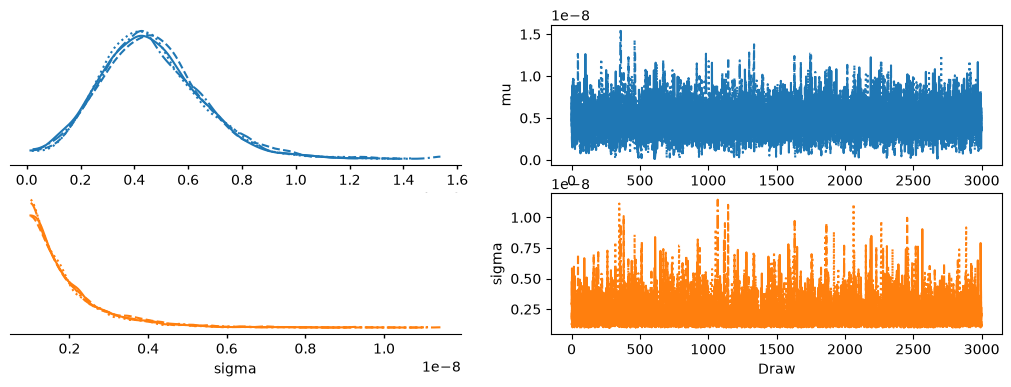

In [ ]:
azp.plot_trace_dist(result, var_names= model_hyperparams, )

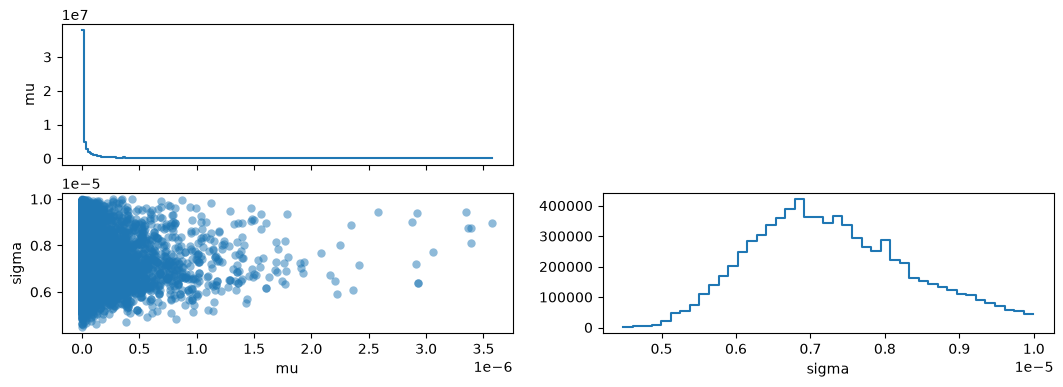

In [ ]:
azp.plot_pair(result, var_names=model_hyperparams, marginal_kind='hist')

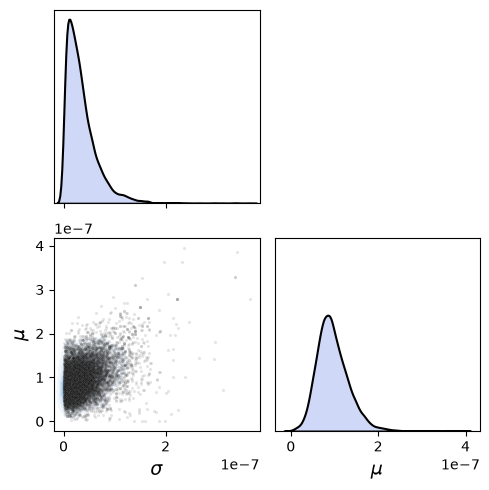

In [ ]:
# seaborn pair plot for two vars

g = sns.PairGrid(result_df[model_hyperparams], corner=True, despine=False)

g.map_diag(sns.kdeplot, fill=True, color="royalblue", edgecolor="black", lw=1.5)
g.map_lower(sns.kdeplot, fill=True, cmap="Blues", thresh=0.05, levels=10)
g.map_lower(sns.scatterplot, color="black", s=5, alpha=0.1)


# axes labels assume hyperparams are ['sigma','mu'], not the biggest deal
g.axes[0, 0].set_xlabel(r"$\sigma$", fontsize=14)
g.axes[1, 0].set_xlabel(r"$\sigma$", fontsize=14)
g.axes[1, 0].set_ylabel(r"$\mu$", fontsize=14)
g.axes[1, 1].set_xlabel(r"$\mu$", fontsize=14)

plt.tight_layout()
plt.show()


## Extras

In [1]:
import csv
# append your hyperparameter posteriors to a csv
def appendToCsv(fileName, data):
    with open('hyperparameter_samples.csv', mode='a', newline='', encoding='utf-8') as file:
        writer = csv.writer(file)
        writer.writerow(mus)


# for if you need to replace the final row in csv with current data
def replaceFinalRow(fileName, data):
    with open("hyperparameter_samples.csv", mode='r', newline='',encoding = 'utf-8') as file:
        reader = csv.reader(file)
        rows = list(reader)

        rows[-1] = mus

    with open('hyperparameter_samples.csv', mode='w', newline='', encoding='utf-8') as file:
        writer = csv.writer(file)
        writer.writerows(rows)


fileName = "hyperparameter_samples.csv"
data = result.posterior['mu'].values.flatten()

#appendToCsv(fileName, data)
#replaceFinalRow(fileName, data)

NameError: name 'result' is not defined

### Diagnostics

In [ ]:

az.ess(result)

<xarray.DataTree 'posterior'>
Group: /posterior
    Dimensions:  ()
    Data variables:
        scale    float64 8B 4.232e+03

In [ ]:

mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     scale      0.02      0.01      0.01      0.00      0.03   4753.77      1.00

Number of divergences: 0


In [ ]:
extra_fields = mcmc.get_extra_fields()

print("\n--- SAMPLER DIAGNOSTICS ---")

# Check the actual acceptance probability (should be around 0.80)
if 'accept_prob' in extra_fields:
    mean_accept = jnp.mean(extra_fields['accept_prob'])
    print(f"Mean Acceptance Probability: {mean_accept:.4f}")
    # If this is 0.0, every single proposal is being rejected

# Check for trajectory divergences
if 'diverging' in extra_fields:
    total_divergences = jnp.sum(extra_fields['diverging'])
    print(f"Total Divergent Transitions: {total_divergences}")
    # If this equals your total number of steps, the gradients are exploding

# Check the step size NUTS adapted to
if 'adapt_state' in extra_fields and hasattr(extra_fields['adapt_state'], 'step_size'):
    print(f"Final Adapted Step Size: {extra_fields['adapt_state'].step_size[-1]}")


--- SAMPLER DIAGNOSTICS ---
Total Divergent Transitions: 0
